In [1]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/optimal-control/code/lec8`


In [2]:
using LinearAlgebra
using SparseArrays
using ControlSystems
using ForwardDiff
using PyPlot
using LaTeXStrings
using JupyterFormatter
import SymPy
enable_autoformat()
PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "Times New Roman")
PyPlot.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

In [10]:
# continuous time system
A_c = [0 1; 0 0];
B_c = [0; 1];

In [11]:
# derive discrete time system using matrix exponential
h_sym = SymPy.Sym("h")
D_sym = SymPy.exp([A_c B_c; 0 0 0] * h_sym)

h = 0.1
# D = SymPy.N(D_sym.subs(h_sym, h))
D = SymPy.convert(Matrix{Float64}, D_sym.subs(h_sym, h))  # sparse matrix is sensitive to the type

A = D[1:2, 1:2]
B = D[1:2, 3]

2-element Vector{Float64}:
 0.005000000000000001
 0.1

In [12]:
# controllability
rank([B A * B])

2

In [13]:
n = size(A)[2]  # number of states
m = length(size(B)) == 1 ? 1 : size(B)[2]  # number of controls
t_final = 5.0  # final time (try larger values, superlinear in computation complexity increase)
t_history = Array(0:h:t_final)
N = length(t_history)  # number of time steps

51

In [14]:
# initial conditions
x0 = [1.0; 0]  # try some other states

2-element Vector{Float64}:
 1.0
 0.0

In [15]:
# cost weights
Q = Array(1.0 * I(n))
R = Array(0.1 * I(m))  # try larger values
Q_N = Array(1.0 * I(n))

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

In [16]:
function J(x_history, u_history)
    cost = 0.5 * x_history[:, end]' * Q_N * x_history[:, end]
    for k = 1:(N-1)
        cost +=
            0.5 * x_history[:, k]' * Q * x_history[:, k] +
            0.5 * (u_history[k]'*R*u_history[k])[1]  # WARNING: Now that R is a matrix instead of real number, the result is a 1x1 matrix, so use index.
    end
    return cost
end

J (generic function with 1 method)

In [17]:
# cost-to-go function
function V_inf(x)
    0.5 * x' * P_inf * x
end
function V(k, x)
    return 0.5 * x' * P[:, :, k] * x
end

V (generic function with 1 method)

In [19]:
# QP solution for xhist, uhist
H = blockdiag(sparse(R), kron(I(N - 2), blockdiag(sparse(Q), sparse(R))), sparse(Q_N));

# constraints
C = kron(I(N - 1), [B -I(n)])
for k = 1:N-2
    C[(k*n).+(1:n), (k*(m+n)-n).+(1:n)] .= A
end
d = [-A * x0; zeros(size(C, 1) - n)];

# solve the linear system
y = [H C'; C zeros(size(C, 1), size(C, 1))] \ [zeros(size(H, 1)); d]

# get Lagrangian multipliers
lambda_history_qp = reshape(y[(size(H, 1)+1):end], n, N - 1)

# Get state history
z = y[1:size(H, 1)]   # states and controls [u0,x1,u1,...,xN]
Z = reshape(z, n + m, N - 1)
x_history_qp = Z[m+1:end, :]
x_history_qp = [x0 x_history_qp]

# Get control history
u_history_qp = Z[1, :];

In [20]:
# dynamic programming solution for P and K
P = zeros(n, n, N)
K = zeros(m, n, N - 1)

P[:, :, N] .= Q_N

# backward riccati recursion
for k = N-1:-1:1
    K[:, :, k] .= (R .+ B' * P[:, :, k+1] * B) \ (B' * P[:, :, k+1] * A)
    P[:, :, k] .=
        Q +
        K[:, :, k]' * R * K[:, :, k] +
        (A - B * K[:, :, k])' * P[:, :, k+1] * (A - B * K[:, :, k])
end

# forward rollout starting at x0
x_history_dp = zeros(n, N)
x_history_dp[:, 1] = x0
u_history_dp = zeros(m, N - 1)
for k = 1:(N-1)
    u_history_dp[:, k] .= -K[:, :, k] * x_history_dp[:, k]
    x_history_dp[:, k+1] .= A * x_history_dp[:, k] + B * u_history_dp[k]
end

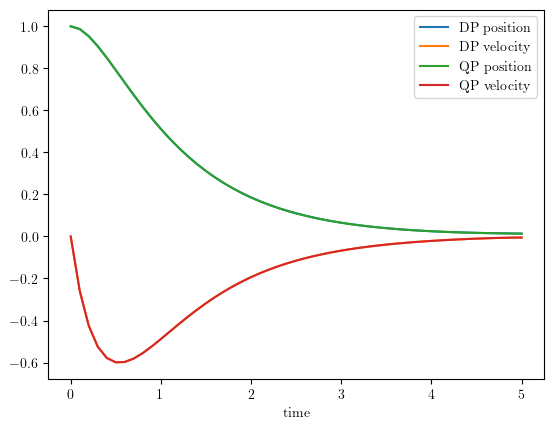

PyObject <matplotlib.legend.Legend object at 0x7f2b0c8bb340>

In [21]:
# Plot x1 vs. x2, u vs. t, x vs. t, etc.
times = range(0, h * (N - 1), step = h)
plot(times, x_history_dp[1, :], label = "DP position")
plot(times, x_history_dp[2, :], label = "DP velocity")
plot(times, x_history_qp[1, :], label = "QP position")
plot(times, x_history_qp[2, :], label = "QP velocity")
xlabel("time")
legend()

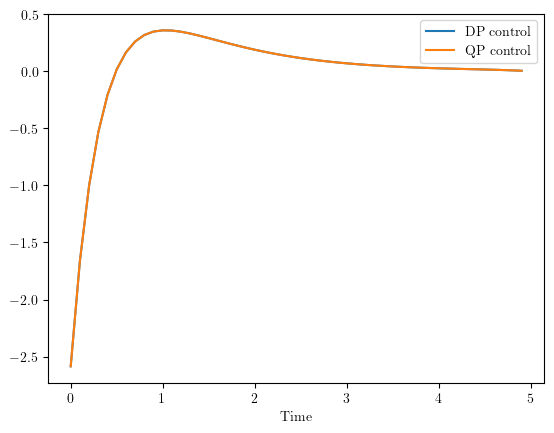

PyObject <matplotlib.legend.Legend object at 0x7f2b004b5ff0>

In [22]:
plot(times[1:end-1], u_history_dp[1, :], label = "DP control")
plot(times[1:end-1], u_history_qp, label = "QP control")
xlabel("Time")
legend()

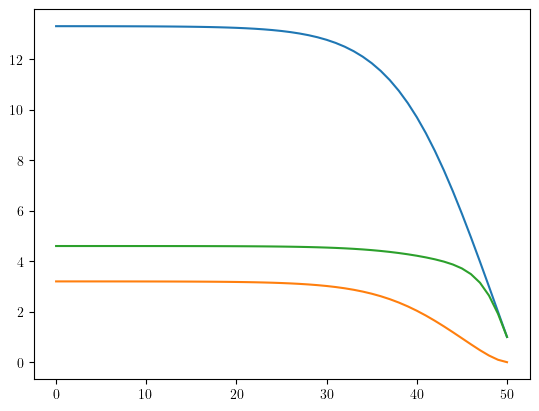

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f2af842f640>

In [23]:
plot(P[1, 1, :])
plot(P[1, 2, :])
plot(P[2, 2, :])

In [24]:
J(x_history_dp, u_history_dp)

6.658133166380839

In [25]:
J(x_history_qp, u_history_qp)

6.658133166380828

In [26]:
#Compute infinite-horizon K matrix using ControlSystems.jl
Kinf = lqr(Discrete, A, B, Q, R)
#Compare to ours
K[:, :, 1] - Kinf

1×2 Matrix{Float64}:
 -0.000277795  -9.44339e-5

In [33]:
#Compute infinite-horizon P matrix
P_inf = are(Discrete, A, B, Q, R)  # dare
#Compare to ours
P[:, :, 1] - P_inf

2×2 Matrix{Float64}:
 -0.000958108  -0.0003257
 -0.0003257    -0.000110719

In [28]:
#Forward rollout starting at xk
function rollout(k, x)
    xsub = zeros(n, N - k + 1)
    xsub[:, 1] .= x
    usub = zeros(m, N - k)
    for j = k:(N-1)
        usub[:, j-k+1] .= -K[:, :, j] * xsub[:, j-k+1]
        xsub[:, j-k+2] .= A * xsub[:, j-k+1] + B * usub[j-k+1]
    end
    return xsub, usub
end

rollout (generic function with 1 method)

In [31]:
#Generate a sub-trajectory starting at xk
k = 50
xsub, usub = rollout(k, x_history_dp[:, k])

#Optimal state sub-trajectories are optimal
xsub - x_history_dp[:, k:end]
#Optimal control sub-trajectories are optimal
usub - u_history_dp[:, k:end]

1×1 Matrix{Float64}:
 0.0

In [34]:
#Compare multipliers from QP to Cost-to-go gradient from DP
@show lambda_history_qp[:, k-1];
@show ForwardDiff.gradient(x -> V(k, x), x_history_dp[:, k]);
#Also compare to infinite horizon
@show ForwardDiff.gradient(x -> V_inf(x), x_history_dp[:, k]);

lambda_history_qp[:, k - 1] = [0.027717781585042824, -0.009334931245780956]
ForwardDiff.gradient((x->begin
            #= In[34]:3 =#
            V(k, x)
        end), x_history_dp[:, k]) = [0.027717781585042924, -0.009334931245780982]
ForwardDiff.gradient((x->begin
            #= In[34]:5 =#
            V_inf(x)
        end), x_history_dp[:, k]) = [0.17029187853134015, 0.019587680561078284]


In [36]:
#Let's try finite diffing the cost w.r.t. the state
x1p, u1p = rollout(k, x_history_dp[:, k] + [1e-6; 0])
x2p, u2p = rollout(k, x_history_dp[:, k] + [0; 1e-6])
λfd =
    [
    J(x1p, u1p) - J(x_history_dp[:, k:end], u_history_dp[:, k:end]),
    J(x2p, u2p) - J(x_history_dp[:, k:end], u_history_dp[:, k:end]),
    ] ./ 1e-6

LoadError: BoundsError: attempt to access 1×1 Matrix{Float64} at index [2]